In [231]:
import pandas as pd
import glob
import os
import pandas as pd
import numpy as np
from functools import reduce


In [232]:
# import data from stats canada
folder_path = "C:\\Users\\15145\\Downloads\\Stat Canada Data\\Altogether"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []
for file in all_files:
    df = pd.read_csv(file)
    df_list.append(df)

# Merge all dataframes
merged_df = pd.concat(df_list, ignore_index=True)

print(f"Total files merged: {len(all_files)}")
print(f"Final shape: {merged_df.shape}")
merged_df.head()

Total files merged: 70
Final shape: (7154352, 60)


,REC_NUM,SURVYEAR,SURVMNTH,LFSSTAT,PROV,CMA,AGE_12,AGE_6,GENDER,MARSTAT,...,LKATADS,LKANSADS,LKOTHERN,PRIORACT,YNOLOOK,TLOLOOK,SCHOOLN,EFAMTYPE,AGYOWNK,FINALWT
0,1,2020,1,1,35,4,7,NaN,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3,3.0,729
1,2,2020,1,1,46,6,7,NaN,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2,NaN,181
2,3,2020,1,3,35,4,2,4.0,2,6,...,1.0,1.0,NaN,3.0,NaN,NaN,1.0,6,NaN,1040
3,4,2020,1,1,35,4,4,NaN,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2,NaN,1421
4,5,2020,1,4,13,0,11,NaN,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,NaN,167


In [237]:
# import data from woodgreen
df_monthly_2024 = pd.read_csv('monthly_registrations_2024.csv', 
                            index_col=0,  # Use first column as index
                            parse_dates=True)  # Parse the date column

In [234]:
# ---------- Base Ontario subset + helpers ----------
ont = merged_df[merged_df["PROV"] == 35].copy()

# Define monthly grouping
group_cols = ["SURVYEAR", "SURVMNTH"]

# Convenience flags
ont["is_employed"]   = ont["LFSSTAT"].isin([1, 2])
ont["is_unemployed"] = ont["LFSSTAT"] == 3

# (Optionally you can restrict to 15+ here if you have AGE)
# ont = ont[ont["AGE"] >= 15]


# ======================================================
# 1) Unemployment levels
#    -> count of unemployed people per month
# ======================================================
monthly_unemployment = (
    ont[ont["is_unemployed"]]
    .groupby(group_cols)
    .size()
    .reset_index(name="unemployed_count")
)


# ======================================================
# 2) Employment-to-population ratio
#    -> employed_count, population_count, ratio
# ======================================================
monthly_population = (
    ont
    .groupby(group_cols)
    .size()
    .reset_index(name="population_count")
)

monthly_employed = (
    ont[ont["is_employed"]]
    .groupby(group_cols)
    .size()
    .reset_index(name="employed_count")
)

emp_pop = (
    monthly_population
    .merge(monthly_employed, on=group_cols, how="left")
    .fillna({"employed_count": 0})
)
emp_pop["employment_to_pop_ratio"] = (
    emp_pop["employed_count"] / emp_pop["population_count"]
)


# ======================================================
# 3) Proportion of part-time vs full-time jobs
#    -> counts & proportions among employed
# ======================================================
emp_with_ftpt = ont[ont["is_employed"] & ont["FTPTMAIN"].notna()].copy()

pt_ft = (
    emp_with_ftpt
    .groupby(group_cols + ["FTPTMAIN"])
    .size()
    .unstack("FTPTMAIN", fill_value=0)
    .reset_index()
)

# columns that correspond to FTPTMAIN categories before renaming
raw_value_cols = [c for c in pt_ft.columns if c not in group_cols]

# rename them for clarity
pt_ft = pt_ft.rename(columns={c: f"count_FTPT_{c}" for c in raw_value_cols})

# recompute list of value cols AFTER renaming
value_cols = [c for c in pt_ft.columns if c.startswith("count_FTPT_")]

pt_ft["total_employed_FTPT"] = pt_ft[value_cols].sum(axis=1)

for c in value_cols:
    pt_ft[f"prop_{c.replace('count_FTPT_', '')}"] = pt_ft[c] / pt_ft["total_employed_FTPT"]


# ======================================================
# 4) Job precariousness metrics
#    Here: permanent vs temporary (PERMTEMP)
#    -> counts & share temporary among employed
# ======================================================
emp_with_permtemp = ont[ont["is_employed"] & ont["PERMTEMP"].notna()].copy()

precarious = (
    emp_with_permtemp
    .groupby(group_cols + ["PERMTEMP"])
    .size()
    .unstack("PERMTEMP", fill_value=0)   # columns will be PERMTEMP codes e.g. 1.0, 2.0, 3.0, 4.0
    .reset_index()
)

# columns corresponding to PERMTEMP categories (likely floats: 1.0, 2.0, 3.0, 4.0)
permtemp_cols = [c for c in precarious.columns if c not in group_cols]

# total employed (any PERMTEMP status)
precarious["total_employed_PERMTEMP"] = precarious[permtemp_cols].sum(axis=1)

# identify the "temporary" code – usually 2 or 2.0
temp_col = None
if 2.0 in permtemp_cols:
    temp_col = 2.0
elif 2 in permtemp_cols:
    temp_col = 2

# compute share of temporary if we found the column
if temp_col is not None:
    precarious["share_temporary"] = (
        precarious[temp_col] / precarious["total_employed_PERMTEMP"]
    )

# ======================================================
# 5) Hourly wages (median/mean)
#    -> monthly mean/median hourly wage among employed
# ======================================================
emp_with_wage = ont[ont["is_employed"] & ont["HRLYEARN"].notna()].copy()

hourly_wage_stats = (
    emp_with_wage
    .groupby(group_cols)
    .agg(
        hourly_wage_mean   = ("HRLYEARN", "mean"),
        hourly_wage_median = ("HRLYEARN", "median"),
        n_with_wage        = ("HRLYEARN", "size"),
    )
    .reset_index()
)


# ======================================================
# 6) Job loss reasons (WHYLEFTN)
#    -> monthly counts by WHYLEFTN category
# ======================================================
job_loss = (
    ont[(~ont["is_employed"]) & ont["WHYLEFTN"].notna()]
    .groupby(group_cols + ["WHYLEFTN"])
    .size()
    .reset_index(name="job_loss_count")
)
# You can pivot if you want one column per reason code:
# job_loss_pivot = job_loss.pivot(index=group_cols, columns="WHYLEFTN", values="job_loss_count").fillna(0)
# Check the data set, and try to pick the ones who left their job with dissastisfaction or anything that makes sense for your data

# ======================================================
# 8) Temporary / seasonal employment (PERMTEMP)
#    -> monthly counts for each PERMTEMP category
# ======================================================
monthly_permtmp = (
    emp_with_permtemp
    .groupby(group_cols + ["PERMTEMP"])
    .size()
    .reset_index(name="permtmp_count")
)


In [235]:
# # ---------------------------
# # Helper: add a monthly date
# # ---------------------------
# def add_date_column(df):
#     df = df.copy()
#     df["date"] = pd.to_datetime({
#         "year": df["SURVYEAR"],
#         "month": df["SURVMNTH"],
#         "day": 1
#     })
#     return df

# # ====================================================
# # 1) Unemployment levels
# # ====================================================
# unemp_plot = add_date_column(monthly_unemployment)

# plt.figure(figsize=(10, 5))
# plt.plot(unemp_plot["date"], unemp_plot["unemployed_count"], marker="o")
# plt.title("Unemployment Count by Month (Ontario)")
# plt.xlabel("Month")
# plt.ylabel("Number of Unemployed People")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # ====================================================
# # 2) Employment-to-population ratio
# # ====================================================
# emp_pop_plot = add_date_column(emp_pop)

# plt.figure(figsize=(10, 5))
# plt.plot(emp_pop_plot["date"], emp_pop_plot["employment_to_pop_ratio"], marker="o")
# plt.title("Employment-to-Population Ratio by Month (Ontario)")
# plt.xlabel("Month")
# plt.ylabel("Employment-to-Population Ratio")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Optionally, also plot employed_count and population_count
# plt.figure(figsize=(10, 5))
# plt.plot(emp_pop_plot["date"], emp_pop_plot["employed_count"], label="Employed")
# plt.plot(emp_pop_plot["date"], emp_pop_plot["population_count"], label="Population (sample)", linestyle="--")
# plt.title("Employed vs Population Count by Month")
# plt.xlabel("Month")
# plt.ylabel("Count")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # ====================================================
# # 3) Part-time vs full-time proportions
# # ====================================================
# pt_ft_plot = add_date_column(pt_ft)

# # Find all proportion columns
# prop_cols = [c for c in pt_ft_plot.columns if c.startswith("prop_FTPT_")]

# plt.figure(figsize=(10, 5))
# for col in prop_cols:
#     plt.plot(pt_ft_plot["date"], pt_ft_plot[col], marker="o", label=col)

# plt.title("Proportion of Full-time vs Part-time Jobs (Employed)")
# plt.xlabel("Month")
# plt.ylabel("Proportion")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # ====================================================
# # 4) Job precariousness: share temporary
# # ====================================================
# precarious_plot = add_date_column(precarious)

# if "share_temporary" in precarious_plot.columns:
#     plt.figure(figsize=(10, 5))
#     plt.plot(precarious_plot["date"], precarious_plot["share_temporary"], marker="o")
#     plt.title("Share of Temporary Jobs among Employed")
#     plt.xlabel("Month")
#     plt.ylabel("Share Temporary")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

# # ====================================================
# # 5) Hourly wages (mean / median)
# # ====================================================
# wage_plot = add_date_column(hourly_wage_stats)

# plt.figure(figsize=(10, 5))
# plt.plot(wage_plot["date"], wage_plot["hourly_wage_mean"], marker="o", label="Mean hourly wage")
# plt.plot(wage_plot["date"], wage_plot["hourly_wage_median"], marker="s", label="Median hourly wage")
# plt.title("Hourly Wages by Month (Employed)")
# plt.xlabel("Month")
# plt.ylabel("Hourly Wage")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()
# # ====================================================
# # 7) Job loss reasons (WHYLEFTN) – multi-line
# # ====================================================
# # If you pivoted earlier: job_loss_pivot = job_loss.pivot(...)
# # and have SURVYEAR, SURVMNTH as index levels.
# try:
#     job_loss_pivot_plot = job_loss_pivot.reset_index()
#     job_loss_pivot_plot = add_date_column(job_loss_pivot_plot)

#     reason_cols = [c for c in job_loss_pivot_plot.columns if c not in ["SURVYEAR", "SURVMNTH", "date"]]

#     plt.figure(figsize=(10, 6))
#     for col in reason_cols:
#         plt.plot(job_loss_pivot_plot["date"], job_loss_pivot_plot[col], marker="o", label=f"Reason {col}")
#     plt.title("Job Loss Reasons by Month")
#     plt.xlabel("Month")
#     plt.ylabel("Count")
#     plt.legend(title="WHYLEFTN")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
# except NameError:
#     # if job_loss_pivot doesn't exist, skip
#     pass


In [236]:

# --- 0. Make sure each partial DF has SURVYEAR, SURVMNTH ---

# 1) monthly_unemployment: [SURVYEAR, SURVMNTH, unemployed_count]
# 2) emp_pop: [SURVYEAR, SURVMNTH, population_count, employed_count, employment_to_pop_ratio]
# 3) pt_ft: [SURVYEAR, SURVMNTH, count_FTPT_*, prop_*]
# 4) precarious: [SURVYEAR, SURVMNTH, <PERMTEMP columns>, total_employed_PERMTEMP, share_temporary]
# 5) hourly_wage_stats: [SURVYEAR, SURVMNTH, hourly_wage_mean, hourly_wage_median, n_with_wage]
# 6) job_loss: build a pivot with total job losses per month

# --- 1. Build a pivoted job_loss table ---
job_loss_pivot = (
    job_loss
    .pivot(index=["SURVYEAR", "SURVMNTH"], columns="WHYLEFTN", values="job_loss_count")
    .fillna(0)
    .reset_index()
)

# todo :  drop columns for pregnancy and stuff
# Compute a total job loss count per month (sum across reasons)
job_loss_cols = [c for c in job_loss_pivot.columns if c not in ["SURVYEAR", "SURVMNTH"]]
job_loss_pivot["job_loss_total"] = job_loss_pivot[job_loss_cols].sum(axis=1)

# Optionally keep only total (simpler, fewer features)
job_loss_pivot = job_loss_pivot[["SURVYEAR", "SURVMNTH", "job_loss_total"]]

# --- 2. Slim down precarious to just share_temporary (and maybe total employment from PERMTEMP) ---
precarious_slim = precarious[["SURVYEAR", "SURVMNTH", "share_temporary", "total_employed_PERMTEMP"]]

# --- 3. Put all feature tables into a list and outer-merge on year/month ---
feature_dfs = [
    monthly_unemployment,
    emp_pop,
    pt_ft,
    precarious_slim,
    hourly_wage_stats,
    job_loss_pivot,
]

monthly_features = reduce(
    lambda left, right: pd.merge(left, right, on=["SURVYEAR", "SURVMNTH"], how="outer"),
    feature_dfs
)

# --- 4. Build a proper datetime column for the month and set as index ---
monthly_features["date"] = pd.to_datetime(
    dict(year=monthly_features["SURVYEAR"],
         month=monthly_features["SURVMNTH"],
         day=1)
)

monthly_features = (
    monthly_features
    .sort_values("date")
    .set_index("date")
)

# --- 5. Handle missing values (simple + safe approach for now) ---
# Forward fill then backward fill (you can refine later)
monthly_features = monthly_features.ffill().bfill()


In [ ]:
import pandas as pd

df_economy = pd.read_csv(
    r"C:\Users\15145\Downloads\df_processed.csv",
    parse_dates=["date"]          # very important
)
df_economy = df_economy.set_index("date")

In [238]:
woodgreen = df_monthly_2024.copy()
woodgreen = woodgreen.sort_index()

monthly_features.index = monthly_features.index.to_period("M").to_timestamp("M")
woodgreen.index = woodgreen.index.to_period("M").to_timestamp("M")
woodgreen.index.name = "date"

In [ ]:
# Merge features (long history) with WoodGreen data (short history)
data = monthly_features.join(woodgreen, how="inner")

# Keep only rows where we have registrations (i.e., Jan 2024–Oct 2025)
data = data.dropna(subset=["registrations"])

            SURVYEAR  SURVMNTH  unemployed_count  population_count  \
date                                                                 
2024-01-31      2024         1              1355             35817   
2024-02-29      2024         2              1394             36002   
2024-03-31      2024         3              1508             36350   
2024-04-30      2024         4              1424             36722   
2024-05-31      2024         5              1553             36988   

            employed_count  employment_to_pop_ratio  count_FTPT_1.0  \
date                                                                  
2024-01-31           20648                 0.576486           16825   
2024-02-29           20755                 0.576496           16838   
2024-03-31           20949                 0.576314           17040   
2024-04-30           21368                 0.581886           17434   
2024-05-31           21824                 0.590029           17899   

           

In [ ]:
# agg_rules = {
#     'USDCAD_ret': 'sum',      # returns accumulate
#     'CPIAUCSL': 'last',       # inflation index uses month-end
# }

# # Everything else → median instead of mean
# for col in df_economy.columns:
#     if col not in agg_rules:
#         agg_rules[col] = 'median'


df_economy.index = df_economy.index.to_period("M").to_timestamp("M")
macro_monthly = (
    df_economy
    .groupby("date")
    .mean(numeric_only=True)
    .sort_index()
)

data_with_macro = data.join(macro_monthly, how="inner")


In [249]:
base_features= [ 'unemployed_count',       'employment_to_pop_ratio',  'prop_1.0', 'prop_2.0',
       'share_temporary', 'hourly_wage_mean',
       'hourly_wage_median', 'job_loss_total','goc_2y_benchmark','spread_10y_2y'] #,'DGS10','DTWEXBGS','FXUSDCAD','CPIAUCSL','TBCDN90DMID','TBCDN180DMID'
#prop_1.0 --> Permenant/total || prop_2.0 ---> Temporarily/FullTime
X = data_with_macro[base_features].copy()
y = data_with_macro["registrations"].copy()

In [202]:
from sklearn.preprocessing import StandardScaler

# Convert to numpy
X_values = X.values.astype(np.float32)
y_values = y.values.astype(np.float32).reshape(-1, 1)

# Time-based split index
test_size = 4   # last 4 months as test set
split_idx = len(X_values) - test_size

X_train, X_test = X_values[:split_idx], X_values[split_idx:]
y_train, y_test = y_values[:split_idx], y_values[split_idx:]

# Fit scaler on TRAIN ONLY (important)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_scaled_all   = scaler_X.transform(X_values)

y_train_scaled = scaler_y.fit_transform(y_train)
y_scaled_all   = scaler_y.transform(y_values)


In [203]:
# import torch
# from torch.utils.data import Dataset, DataLoader

# class TimeSeriesDataset(Dataset):
#     def __init__(self, X, y, input_window):
#         """
#         X: np.array of shape (T, n_features)
#         y: np.array of shape (T, 1)
#         input_window: number of time steps in the input sequence
#         """
#         self.X = X
#         self.y = y
#         self.input_window = input_window
        
#         # We can create sequences until len - input_window - 1
#         print(len(X),input_window)
#         self.length = len(X) - input_window

#     def __len__(self):
#         # print(self.y.shape)
#         return self.length

#     def __getitem__(self, idx):
#         # Input: [idx : idx+input_window)
#         x_seq = self.X[idx : idx + self.input_window]
#         # Target: predict the next time step y at idx+input_window
#         y_target = self.y[idx + self.input_window]
        
#         # Shape them as (seq_len, n_features) and (1,)
#         return torch.from_numpy(x_seq), torch.from_numpy(y_target)

# input_window = 5

# train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, input_window)
# test_dataset  = TimeSeriesDataset(X_test_scaled,  y_test_scaled,  input_window)

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

# print("Train sequences:", len(train_dataset))
# print("Test sequences:", len(test_dataset))


In [204]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

X_values = X_values.astype(np.float32)
y_values = y_values.astype(np.float32).reshape(-1, 1)

T = len(X_values)
W = 6    # or 12, etc.
H = 4    # forecast horizon
class WindowedDataset(Dataset):
    def __init__(self, X, y_scaled, input_window, target_indices):
        self.X = X
        self.y = y_scaled
        self.input_window = input_window
        self.target_indices = target_indices

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, idx):
        target_idx = self.target_indices[idx] # 11
        start = target_idx - self.input_window # 7
        end = target_idx # 11
        x_seq = self.X[start:end]          # (W, n_features)
        y_target = self.y[target_idx]      # (1,)
        return torch.from_numpy(x_seq), torch.from_numpy(y_target)

# # All possible target indices we can build a window for:
all_target_indices = list(range(W, T))  # because we need W history points


# # Define cutoff between train and test based on target time
test_start = T - H
train_target_indices = [i for i in all_target_indices if i < test_start] # [6,7,8,9,10,11..,15]
test_target_indices  = [i for i in all_target_indices if i >= test_start] # [16,17,18,19]


train_dataset = WindowedDataset(X_scaled_all, y_scaled_all, W, train_target_indices)
test_dataset  = WindowedDataset(X_scaled_all, y_scaled_all, W, test_target_indices)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [257]:
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, output_features = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,   # (batch, seq, feature)
        )
        
        # Final regression layer: from hidden state -> scalar
        self.fc = nn.Linear(hidden_size, output_features)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        batch_size = x.size(0)
        
        # Initialize hidden and cell with zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        
        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_len, hidden_size)
        
        # Use last time step's hidden state
        last_hidden = out[:, -1, :]      # (batch, hidden_size)
        # print(out.shape)
        
        prediction = self.fc(last_hidden)  # (batch, 1)
        return prediction


In [225]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_features = X_train_scaled.shape[1]
model = LSTMForecaster(n_features=n_features, hidden_size=8, num_layers=2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 400

for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)          # (batch, seq_len, n_features)
        y_batch = y_batch.to(device)          # (batch, 1)
        
        optimizer.zero_grad()
        outputs = model(X_batch)              # (batch, 1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_dataset)
    
    # Simple validation on test set
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(test_dataset)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 001 | Train Loss: 1.4696 | Val Loss: 0.0611
Epoch 010 | Train Loss: 1.3927 | Val Loss: 0.0748
Epoch 020 | Train Loss: 1.3171 | Val Loss: 0.0938
Epoch 030 | Train Loss: 1.2286 | Val Loss: 0.1154
Epoch 040 | Train Loss: 1.1153 | Val Loss: 0.1289
Epoch 050 | Train Loss: 0.9685 | Val Loss: 0.1352
Epoch 060 | Train Loss: 0.8305 | Val Loss: 0.1273
Epoch 070 | Train Loss: 0.6993 | Val Loss: 0.1126
Epoch 080 | Train Loss: 0.5894 | Val Loss: 0.0984
Epoch 090 | Train Loss: 0.5000 | Val Loss: 0.1075
Epoch 100 | Train Loss: 0.4295 | Val Loss: 0.1175
Epoch 110 | Train Loss: 0.3691 | Val Loss: 0.1304
Epoch 120 | Train Loss: 0.3203 | Val Loss: 0.1333
Epoch 130 | Train Loss: 0.2796 | Val Loss: 0.1745
Epoch 140 | Train Loss: 0.2412 | Val Loss: 0.1764
Epoch 150 | Train Loss: 0.2068 | Val Loss: 0.2086
Epoch 160 | Train Loss: 0.1797 | Val Loss: 0.2120
Epoch 170 | Train Loss: 0.1543 | Val Loss: 0.2688
Epoch 180 | Train Loss: 0.1313 | Val Loss: 0.2849
Epoch 190 | Train Loss: 0.1129 | Val Loss: 0.2986


In [226]:
model.eval()
preds_scaled = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)          # (batch, 1) in scaled space
        preds_scaled.append(outputs.cpu().numpy())

# Stack to shape (n_test_samples, 1)
preds_scaled = np.vstack(preds_scaled)

# Invert scaling on y
preds = scaler_y.inverse_transform(preds_scaled).flatten()  # back to original scale

# --- Align predictions with dates using test_target_indices ---

# Make sure indices are sorted (they should be, but just to be safe)
test_target_indices_sorted = sorted(test_target_indices)

# Get corresponding dates from the original data index
pred_dates = data.index[test_target_indices_sorted]

# Build prediction series
pred_series = pd.Series(preds, index=pred_dates, name="predicted_registrations")

# True values at those target indices
true_series = y.iloc[test_target_indices_sorted]
true_series.name = "true_registrations"

print(pred_series.head())
print(true_series.head())


date
2025-07-31    254.417923
2025-08-31    244.301773
2025-09-30    225.651489
2025-10-31    210.958130
Name: predicted_registrations, dtype: float32
date
2025-07-31    156
2025-08-31    149
2025-09-30    131
2025-10-31     91
Name: true_registrations, dtype: int64


In [227]:
test_target_indices_sorted

[18, 19, 20, 21]

RMSE: 102.61 | MAE: 102.08


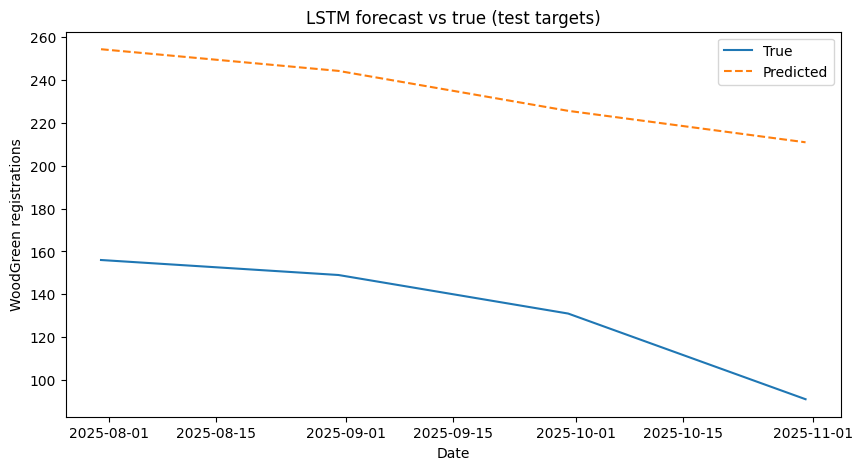

In [228]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

rmse = np.sqrt(mean_squared_error(true_series, pred_series))
mae  = mean_absolute_error(true_series, pred_series)
print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(true_series.index, true_series.values, label="True")
plt.plot(pred_series.index, pred_series.values, label="Predicted", linestyle="--")
plt.xlabel("Date")
plt.ylabel("WoodGreen registrations")
plt.title("LSTM forecast vs true (test targets)")
plt.legend()
plt.show()


In [223]:
# 1. Check training vs test distribution
print("Train y stats:")
print("  mean:", float(y.iloc[train_target_indices].mean()))
print("  std :", float(y.iloc[train_target_indices].std()))
print("\nTest y stats:")
print("  mean:", float(y.iloc[test_target_indices].mean()))
print("  std :", float(y.iloc[test_target_indices].std()))

# 2. Check model outputs in scaled space
model.eval()
scaled_outputs = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        out = model(X_batch)
        scaled_outputs.append(out.cpu().numpy())

scaled_outputs = np.vstack(scaled_outputs).flatten()
print("\nScaled outputs (first 10):", scaled_outputs[:10])
print("Mean of scaled outputs:", scaled_outputs.mean())


Train y stats:
  mean: 185.83333333333334
  std : 133.84172017949433

Test y stats:
  mean: 131.75
  std : 29.136174537276965

Scaled outputs (first 10): [ 0.48910916  0.47314155  0.34539014 -0.0829871 ]
Mean of scaled outputs: 0.30616343


In [224]:
# feature engineering : job loss, add more columns
# add dataset , economy .. 
# predict future
# make it weekly

In [252]:
# ============================================================
# STEP 1: Train LSTM on Long Sequence (monthly_features)
# Goal: Learn to predict economic features from historical data
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import StandardScaler

print("Shape of monthly_features:", monthly_features.shape)
print("Date range:", monthly_features.index.min(), "to", monthly_features.index.max())

Shape of monthly_features: (70, 17)
Date range: 2020-01-31 00:00:00 to 2025-10-31 00:00:00


In [253]:
# Select features to train on from monthly_features
# Using the same base features as before
feature_cols = [
    'unemployed_count',
    'employment_to_pop_ratio',
    'prop_1.0',
    'prop_2.0',
    'share_temporary',
    'hourly_wage_mean',
    'hourly_wage_median',
    'job_loss_total'
]

# Extract features from monthly_features
X_long = monthly_features[feature_cols].copy()
print(f"Training data shape: {X_long.shape}")
print(f"Date range: {X_long.index.min()} to {X_long.index.max()}")
print(f"\nFeature columns:\n{feature_cols}")

Training data shape: (70, 8)
Date range: 2020-01-31 00:00:00 to 2025-10-31 00:00:00

Feature columns:
['unemployed_count', 'employment_to_pop_ratio', 'prop_1.0', 'prop_2.0', 'share_temporary', 'hourly_wage_mean', 'hourly_wage_median', 'job_loss_total']


In [254]:
# Convert to numpy and prepare for LSTM
X_long_values = X_long.values.astype(np.float32)

# Scale the features
scaler_long = StandardScaler()
X_long_scaled = scaler_long.fit_transform(X_long_values)

print(f"Scaled data shape: {X_long_scaled.shape}")
print(f"Total months of data: {len(X_long_scaled)}")

Scaled data shape: (70, 8)
Total months of data: 70


In [255]:
# Create Dataset for feature prediction
# Goal: Given a window of past features, predict the next time step's features

class FeaturePredictionDataset(Dataset):
    """
    Dataset for predicting features at time t given features at times [t-W, ..., t-1]
    """
    def __init__(self, X, input_window, target_indices):
        """
        X: scaled feature array of shape (T, n_features)
        input_window: number of time steps to look back
        target_indices: list of indices we want to predict
        """
        self.X = X
        self.input_window = input_window
        self.target_indices = target_indices
    
    def __len__(self):
        return len(self.target_indices)
    
    def __getitem__(self, idx):
        target_idx = self.target_indices[idx]
        start = target_idx - self.input_window
        end = target_idx
        
        # Input: window of features
        x_seq = self.X[start:end]  # (W, n_features)
        
        # Target: features at next time step
        y_target = self.X[target_idx]  # (n_features,)
        
        return torch.from_numpy(x_seq), torch.from_numpy(y_target)

# Parameters
WINDOW_SIZE = 6  # Look back 6 months to predict next month's features
HORIZON = 6      # Hold out last 6 months for validation

# Create indices
T_long = len(X_long_scaled)
all_indices = list(range(WINDOW_SIZE, T_long))
val_start = T_long - HORIZON

train_indices_long = [i for i in all_indices if i < val_start]
val_indices_long = [i for i in all_indices if i >= val_start]

print(f"Total samples: {len(all_indices)}")
print(f"Training samples: {len(train_indices_long)}")
print(f"Validation samples: {len(val_indices_long)}")

# Create datasets
train_dataset_long = FeaturePredictionDataset(X_long_scaled, WINDOW_SIZE, train_indices_long)
val_dataset_long = FeaturePredictionDataset(X_long_scaled, WINDOW_SIZE, val_indices_long)

# Create dataloaders
BATCH_SIZE = 16
train_loader_long = DataLoader(train_dataset_long, batch_size=BATCH_SIZE, shuffle=True)
val_loader_long = DataLoader(val_dataset_long, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatches per epoch: {len(train_loader_long)}")

Total samples: 64
Training samples: 58
Validation samples: 6

Batches per epoch: 4


In [258]:

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_features = X_long_scaled.shape[1]

model_long = LSTMForecaster(
    n_features=n_features,
    hidden_size=64,
    num_layers=2,
    output_features=n_features
).to(device)

print(f"Model initialized on {device}")
print(f"Model parameters: {sum(p.numel() for p in model_long.parameters()):,}")
print(f"\nModel architecture:")
print(model_long)

Model initialized on cpu
Model parameters: 52,744

Model architecture:
LSTMForecaster(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=8, bias=True)
)


In [288]:
X_long_scaled.shape

(70, 8)

In [260]:
# Training setup
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_long.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20
)

# Training loop
N_EPOCHS = 300
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training on long sequence...\n")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Val Loss':<12} {'LR':<10}")
print("-" * 45)

for epoch in range(1, N_EPOCHS + 1):
    # Training
    model_long.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader_long:
        X_batch = X_batch.to(device)  # (batch, seq_len, n_features)
        y_batch = y_batch.to(device)  # (batch, n_features)
        
        optimizer.zero_grad()
        outputs = model_long(X_batch)  # (batch, n_features)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model_long.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_dataset_long)
    train_losses.append(train_loss)
    
    # Validation
    model_long.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader_long:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model_long(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    val_loss /= len(val_dataset_long)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_long.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'scaler': scaler_long,
            'feature_cols': feature_cols,
        }, 'best_lstm_feature_predictor.pth')
    
    # Print progress
    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"{epoch:<6} {train_loss:<12.6f} {val_loss:<12.6f} {current_lr:<10.6f}")

print(f"\nTraining complete! Best validation loss: {best_val_loss:.6f}")

Starting training on long sequence...

Epoch  Train Loss   Val Loss     LR        
---------------------------------------------
1      0.785218     1.089951     0.001000  
10     0.419908     0.744195     0.001000  
20     0.253356     0.733149     0.001000  
30     0.089266     0.293623     0.001000  
40     0.049812     0.177184     0.001000  
50     0.036185     0.164317     0.001000  
60     0.027482     0.149909     0.001000  
70     0.023496     0.158243     0.001000  
80     0.016327     0.141453     0.001000  
90     0.012700     0.136636     0.001000  
100    0.010479     0.136495     0.000500  
110    0.009484     0.138179     0.000500  
120    0.008885     0.135319     0.000500  
130    0.007985     0.132547     0.000250  
140    0.007663     0.130854     0.000250  
150    0.007320     0.131100     0.000125  
160    0.007165     0.132091     0.000125  
170    0.006992     0.132364     0.000063  
180    0.006911     0.131963     0.000063  
190    0.006823     0.131466     0.

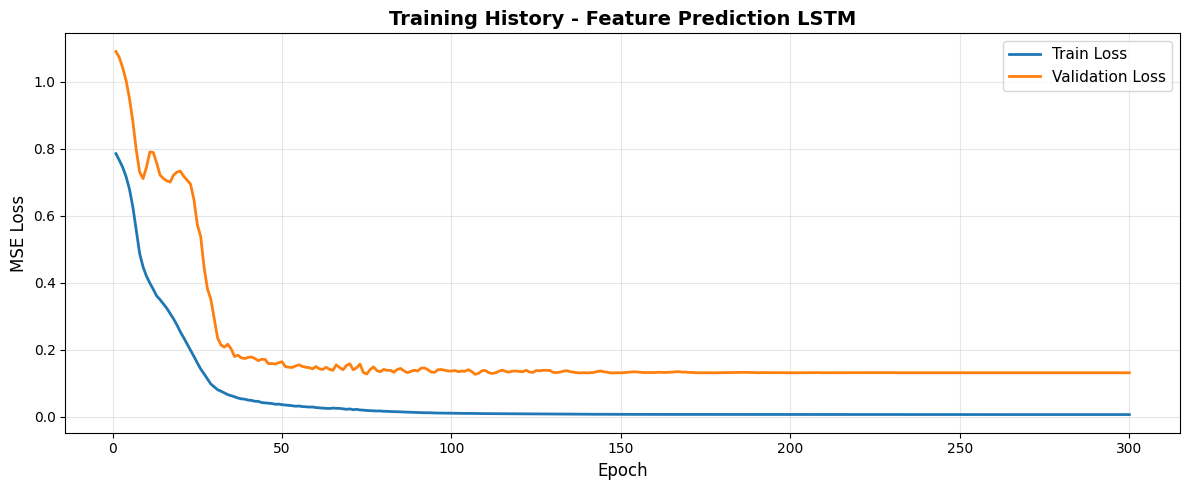

Final training loss: 0.006635
Final validation loss: 0.131373
Best validation loss: 0.126636


In [261]:
# Plot training history
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label='Train Loss', linewidth=2)
ax.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training History - Feature Prediction LSTM', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")

In [262]:
# Evaluate predictions on validation set
model_long.eval()
val_predictions = []
val_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader_long:
        X_batch = X_batch.to(device)
        outputs = model_long(X_batch)
        val_predictions.append(outputs.cpu().numpy())
        val_targets.append(y_batch.numpy())

val_predictions = np.vstack(val_predictions)
val_targets = np.vstack(val_targets)

# Compute metrics per feature
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*70)
print("VALIDATION SET PERFORMANCE (scaled space)")
print("="*70)
print(f"{'Feature':<30} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
print("-"*70)

for i, feat_name in enumerate(feature_cols):
    rmse = np.sqrt(mean_squared_error(val_targets[:, i], val_predictions[:, i]))
    mae = mean_absolute_error(val_targets[:, i], val_predictions[:, i])
    r2 = r2_score(val_targets[:, i], val_predictions[:, i])
    print(f"{feat_name:<30} {rmse:<12.4f} {mae:<12.4f} {r2:<12.4f}")

# Overall metrics
overall_rmse = np.sqrt(mean_squared_error(val_targets, val_predictions))
overall_mae = mean_absolute_error(val_targets, val_predictions)
print("-"*70)
print(f"{'OVERALL':<30} {overall_rmse:<12.4f} {overall_mae:<12.4f}")
print("="*70)


VALIDATION SET PERFORMANCE (scaled space)
Feature                        RMSE         MAE          R²          
----------------------------------------------------------------------
unemployed_count               0.3764       0.3346       0.6557      
employment_to_pop_ratio        0.2492       0.2001       -1.1437     
prop_1.0                       0.4131       0.3827       0.6551      
prop_2.0                       0.4494       0.4031       0.5919      
share_temporary                0.4983       0.4324       0.5403      
hourly_wage_mean               0.1223       0.1070       0.1140      
hourly_wage_median             0.2688       0.2430       0.0764      
job_loss_total                 0.3730       0.3480       -1.7760     
----------------------------------------------------------------------
OVERALL                        0.3625       0.3064      


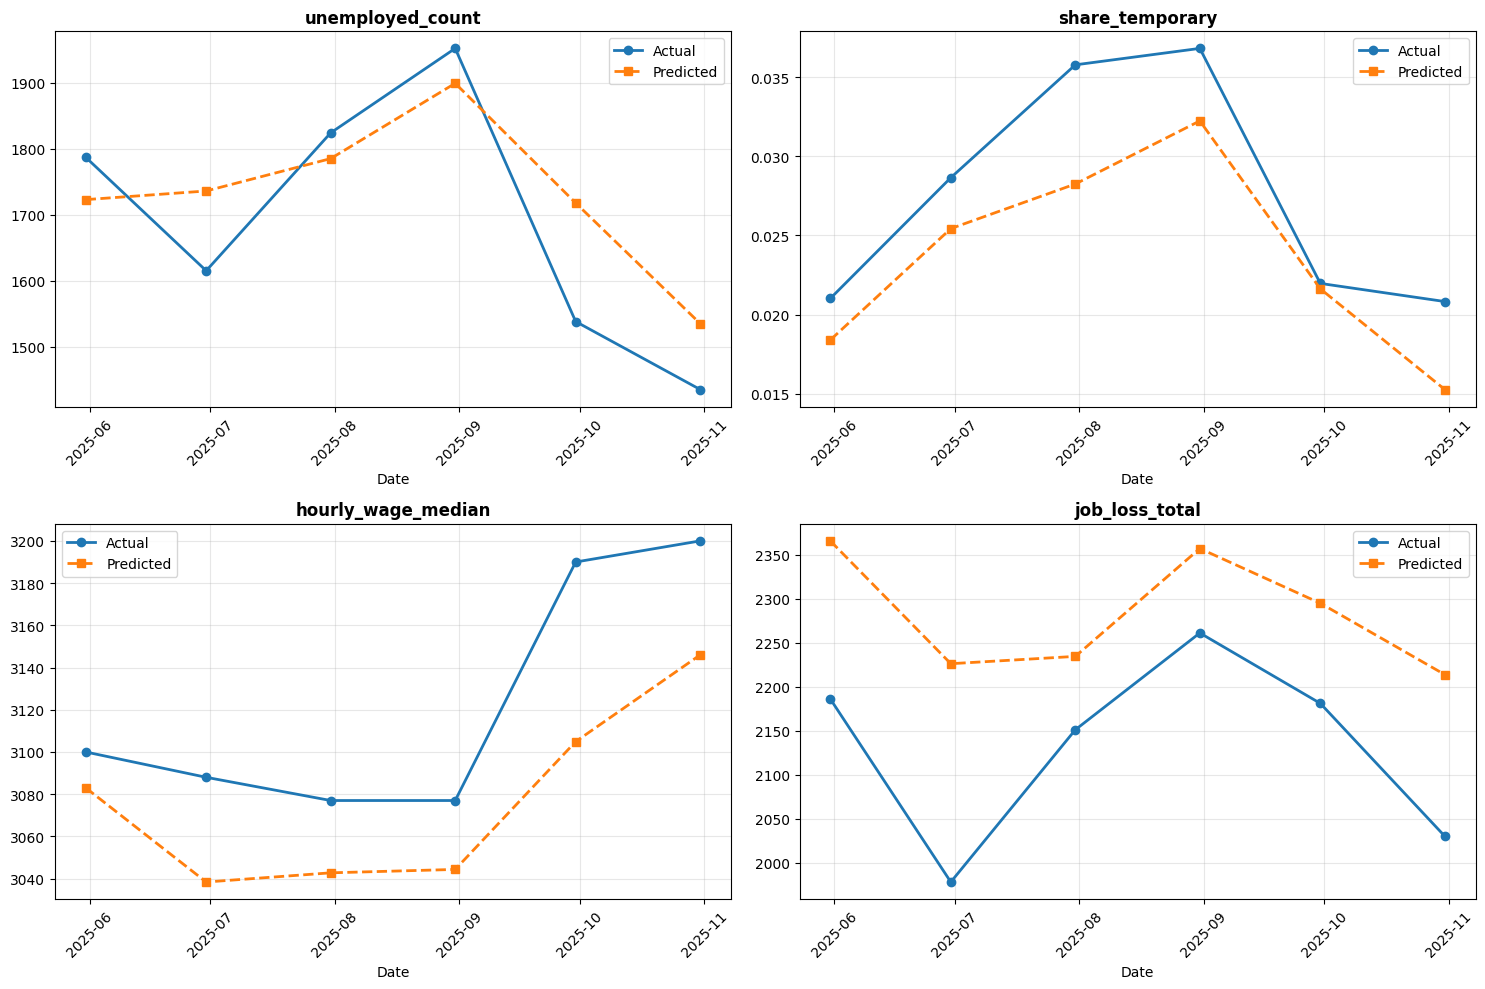

In [264]:
# Visualize predictions vs actual for a few key features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Get the validation dates
val_dates = X_long.index[val_indices_long]

# Select 4 features to visualize
features_to_plot = [
    'unemployed_count',
    'share_temporary',
    'hourly_wage_median',
    'job_loss_total'
]

for idx, feat in enumerate(features_to_plot):
    feat_idx = feature_cols.index(feat)
    
    # Inverse transform to original scale for better interpretability
    pred_original = scaler_long.inverse_transform(val_predictions)[:, feat_idx]
    true_original = scaler_long.inverse_transform(val_targets)[:, feat_idx]
    
    axes[idx].plot(val_dates, true_original, 'o-', label='Actual', linewidth=2, markersize=6)
    axes[idx].plot(val_dates, pred_original, 's--', label='Predicted', linewidth=2, markersize=6)
    axes[idx].set_title(f'{feat}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date', fontsize=10)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [268]:
# ============================================================
# STEP 1: Prepare Woodgreen Data with Autoregressive Features
# ============================================================

print("="*70)
print("PREPARING WOODGREEN DATA FOR FINE-TUNING")
print("="*70)

# Create autoregressive features (lagged registrations)
N_LAGS = 2  # Use previous 3 months of registrations as features

woodgreen_features = data_with_macro.copy()

for lag in range(1, N_LAGS + 1):
    woodgreen_features[f'registrations_lag_{lag}'] = woodgreen_features['registrations'].shift(lag)

# Drop rows with NaN (first N_LAGS rows)
woodgreen_features = woodgreen_features.dropna()

print(f"\nOriginal data shape: {data_with_macro.shape}")
print(f"Data shape after adding {N_LAGS} lags: {woodgreen_features.shape}")
print(f"Date range: {woodgreen_features.index.min()} to {woodgreen_features.index.max()}")

# Display the new features
print(f"\nSample of data with autoregressive features:")
print(woodgreen_features[['registrations', 'registrations_lag_1', 'registrations_lag_2']].head(10))

PREPARING WOODGREEN DATA FOR FINE-TUNING

Original data shape: (22, 43)
Data shape after adding 2 lags: (20, 45)
Date range: 2024-03-31 00:00:00 to 2025-10-31 00:00:00

Sample of data with autoregressive features:
            registrations  registrations_lag_1  registrations_lag_2
date                                                               
2024-03-31            119                 72.0                 52.0
2024-04-30            114                119.0                 72.0
2024-05-31            171                114.0                119.0
2024-06-30            152                171.0                114.0
2024-07-31            538                152.0                171.0
2024-08-31            269                538.0                152.0
2024-09-30            217                269.0                538.0
2024-10-31            205                217.0                269.0
2024-11-30            178                205.0                217.0
2024-12-31             51             

In [269]:
# ============================================================
# STEP 2: Define Features and Create Dataset
# ============================================================

# Base economic features (same as before)
economic_features = [
    'unemployed_count',
    'employment_to_pop_ratio',
    'prop_1.0',
    'prop_2.0',
    'share_temporary',
    'hourly_wage_mean',
    'hourly_wage_median',
    'job_loss_total'
]

# Macro economic features
macro_features = ['goc_2y_benchmark', 'spread_10y_2y']

# Autoregressive features (lagged registrations)
ar_features = [f'registrations_lag_{i}' for i in range(1, N_LAGS + 1)]

# Combine all features
all_features_wg = economic_features + macro_features + ar_features

print(f"{'Feature Category':<25} {'Count':<10} {'Features'}")
print("-"*70)
print(f"{'Economic':<25} {len(economic_features):<10} {', '.join(economic_features[:3])}...")
print(f"{'Macro':<25} {len(macro_features):<10} {', '.join(macro_features)}")
print(f"{'Autoregressive':<25} {len(ar_features):<10} {', '.join(ar_features)}")
print(f"{'TOTAL':<25} {len(all_features_wg):<10}")
print("-"*70)

# Extract features and target
X_woodgreen = woodgreen_features[all_features_wg].copy()
y_woodgreen = woodgreen_features['registrations'].copy()

print(f"\nX_woodgreen shape: {X_woodgreen.shape}")
print(f"y_woodgreen shape: {y_woodgreen.shape}")
print(f"Date range: {X_woodgreen.index.min()} to {X_woodgreen.index.max()}")

Feature Category          Count      Features
----------------------------------------------------------------------
Economic                  8          unemployed_count, employment_to_pop_ratio, prop_1.0...
Macro                     2          goc_2y_benchmark, spread_10y_2y
Autoregressive            2          registrations_lag_1, registrations_lag_2
TOTAL                     12        
----------------------------------------------------------------------

X_woodgreen shape: (20, 12)
y_woodgreen shape: (20,)
Date range: 2024-03-31 00:00:00 to 2025-10-31 00:00:00


In [270]:
# ============================================================
# STEP 3: Create Multi-step Prediction Dataset Class
# ============================================================

class WoodgreenDataset(Dataset):
    """
    Dataset for Woodgreen registrations with multi-step prediction capability
    """
    def __init__(self, X, y, input_window, forecast_horizon, target_indices):
        """
        X: feature array of shape (T, n_features)
        y: target array of shape (T,)
        input_window: number of time steps to look back
        forecast_horizon: number of time steps to predict ahead (1 for single-step)
        target_indices: list of indices we want to predict
        """
        self.X = X
        self.y = y
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        self.target_indices = target_indices

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, idx):
        target_idx = self.target_indices[idx]
        start = target_idx - self.input_window
        end = target_idx

        # Input: window of features
        x_seq = self.X[start:end]  # (W, n_features)

        # Target: either single value or multiple future values
        if self.forecast_horizon == 1:
            # Single-step prediction
            y_target = self.y[target_idx:target_idx+1]  # (1,)
        else:
            # Multi-step prediction
            y_target = self.y[target_idx:target_idx+self.forecast_horizon]  # (H,)

        return torch.from_numpy(x_seq), torch.from_numpy(y_target)

print("✓ WoodgreenDataset class defined")
print("  - Supports variable forecast horizons (1 to N months ahead)")
print("  - Uses windowed input sequences")
print("  - Compatible with autoregressive features")

✓ WoodgreenDataset class defined
  - Supports variable forecast horizons (1 to N months ahead)
  - Uses windowed input sequences
  - Compatible with autoregressive features


In [271]:
# ============================================================
# STEP 4: Prepare Data and Create Train/Test Split
# ============================================================

# Convert to numpy
X_wg_values = X_woodgreen.values.astype(np.float32)
y_wg_values = y_woodgreen.values.astype(np.float32)

# Configuration parameters
TEST_SIZE = 4           # Last 4 months for testing
WINDOW_SIZE_WG = 4      # Look back 4 months
FORECAST_HORIZON = 1    # Predict 1 month ahead (change to 3 or 6 for multi-step)

print(f"\n{'Parameter':<25} {'Value':<10}")
print("-"*35)
print(f"{'Total samples':<25} {len(X_wg_values):<10}")
print(f"{'Window size':<25} {WINDOW_SIZE_WG:<10}")
print(f"{'Forecast horizon':<25} {FORECAST_HORIZON:<10}")
print(f"{'Test size':<25} {TEST_SIZE:<10}")
print("-"*35)

# Scale features and target
scaler_X_wg = StandardScaler()
scaler_y_wg = StandardScaler()

# Fit on ALL data (we have limited data for Woodgreen)
X_wg_scaled = scaler_X_wg.fit_transform(X_wg_values)
y_wg_scaled = scaler_y_wg.fit_transform(y_wg_values.reshape(-1, 1)).flatten()

# Create indices for train/test split
T_wg = len(X_wg_scaled)
max_target_idx = T_wg - FORECAST_HORIZON + 1
all_indices_wg = list(range(WINDOW_SIZE_WG, max_target_idx))

# Time-based split
test_start_idx = max_target_idx - TEST_SIZE
train_indices_wg = [i for i in all_indices_wg if i < test_start_idx]
test_indices_wg = [i for i in all_indices_wg if i >= test_start_idx]

print(f"\nData split:")
print(f"  Total available samples: {len(all_indices_wg)}")
print(f"  Training samples: {len(train_indices_wg)}")
print(f"  Test samples: {len(test_indices_wg)}")

# Create datasets
train_dataset_wg = WoodgreenDataset(
    X_wg_scaled, y_wg_scaled, WINDOW_SIZE_WG, FORECAST_HORIZON, train_indices_wg
)
test_dataset_wg = WoodgreenDataset(
    X_wg_scaled, y_wg_scaled, WINDOW_SIZE_WG, FORECAST_HORIZON, test_indices_wg
)

# Create dataloaders
BATCH_SIZE_WG = 4  # Small batch size for limited data
train_loader_wg = DataLoader(train_dataset_wg, batch_size=BATCH_SIZE_WG, shuffle=True)
test_loader_wg = DataLoader(test_dataset_wg, batch_size=BATCH_SIZE_WG, shuffle=False)

print(f"\nDataLoaders created:")
print(f"  Training batches: {len(train_loader_wg)}")
print(f"  Test batches: {len(test_loader_wg)}")


Parameter                 Value     
-----------------------------------
Total samples             20        
Window size               4         
Forecast horizon          1         
Test size                 4         
-----------------------------------

Data split:
  Total available samples: 16
  Training samples: 12
  Test samples: 4

DataLoaders created:
  Training batches: 3
  Test batches: 1


In [280]:
# ============================================================
# STEP 5: Load Pre-trained Model and Prepare for Fine-tuning
# ============================================================

print("="*70)
print("LOADING PRE-TRAINED MODEL FOR FINE-TUNING")
print("="*70)

# Create new model for Woodgreen (different input size due to additional features)
n_features_wg = X_wg_scaled.shape[1]

model_finetuned = LSTMForecaster(
    n_features=n_features_wg,
    hidden_size=64,
    num_layers=2,
    output_features=FORECAST_HORIZON
).to(device)

# Load pre-trained weights where possible
try:
    checkpoint = torch.load('best_lstm_feature_predictor.pth', map_location=device)
    
    # Load LSTM weights (these transfer well across similar tasks)
    pretrained_state = checkpoint['model_state_dict']
    model_state = model_finetuned.state_dict()
    
    # Copy LSTM layer weights (skip fully connected layer due to different output size)
    pretrained_lstm = {k: v for k, v in pretrained_state.items() 
                      if 'lstm' in k and k in model_state and v.shape == model_state[k].shape}
    
    # Update model state
    model_state.update(pretrained_lstm)
    model_finetuned.load_state_dict(model_state, strict=False)
    
    print("\n✓ Pre-trained LSTM weights loaded successfully")
    print(f"  Loaded {len(pretrained_lstm)} LSTM parameter tensors")
    print("  FC layer initialized randomly (different output dimension)")
    
except FileNotFoundError:
    print("\n⚠ No pre-trained model found. Training from scratch.")
except Exception as e:
    print(f"\n⚠ Could not load pre-trained weights: {e}")
    print("  Training from scratch instead.")

print(f"\nModel configuration:")
print(f"  Input features: {n_features_wg}")
print(f"  Hidden size: 64")
print(f"  LSTM layers: 2")
print(f"  Output dimension: {FORECAST_HORIZON}")
print(f"  Total parameters: {sum(p.numel() for p in model_finetuned.parameters()):,}")

LOADING PRE-TRAINED MODEL FOR FINE-TUNING

⚠ Could not load pre-trained weights: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL sklearn.preprocessing._data.StandardScaler was not an allowed global by default. Please use `torch.serialization.add_safe_globals([sklearn.preprocessing._data.StandardScaler])` or the `torch.serialization.safe_globals([sklearn.preprocessing._data.StandardScaler])` context manager to allowlist

In [281]:
model_finetuned.state_dict().keys()

odict_keys(['lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'fc.weight', 'fc.bias'])

In [282]:
# ============================================================
# STEP 6: Fine-tune the Model on Woodgreen Data
# ============================================================

print("\n" + "="*70)
print("FINE-TUNING ON WOODGREEN DATA")
print("="*70)

# Training setup with lower learning rate for fine-tuning
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_finetuned.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15
)

# Training loop
N_EPOCHS_FINETUNE = 200
train_losses_ft = []
test_losses_ft = []
best_test_loss = float('inf')

print(f"\n{'Epoch':<8} {'Train Loss':<14} {'Test Loss':<14} {'LR':<12}")
print("-"*50)

for epoch in range(1, N_EPOCHS_FINETUNE + 1):
    # Training
    model_finetuned.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader_wg:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model_finetuned(X_batch)
        
        # Ensure output and target have same shape
        if FORECAST_HORIZON == 1:
            outputs = outputs.squeeze(-1)
            y_batch = y_batch.squeeze(-1)
        
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_finetuned.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_dataset_wg)
    train_losses_ft.append(train_loss)
    
    # Testing
    model_finetuned.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader_wg:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model_finetuned(X_batch)
            
            if FORECAST_HORIZON == 1:
                outputs = outputs.squeeze(-1)
                y_batch = y_batch.squeeze(-1)
            
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
    
    test_loss /= len(test_dataset_wg)
    test_losses_ft.append(test_loss)
    
    # Learning rate scheduling
    scheduler.step(test_loss)
    
    # Save best model
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_finetuned.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
            'scaler_X': scaler_X_wg,
            'scaler_y': scaler_y_wg,
            'feature_cols': all_features_wg,
            'forecast_horizon': FORECAST_HORIZON,
        }, 'best_lstm_woodgreen_finetuned.pth')
    
    # Print progress
    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"{epoch:<8} {train_loss:<14.6f} {test_loss:<14.6f} {current_lr:<12.8f}")

print(f"\nFine-tuning complete! Best test loss: {best_test_loss:.6f}")
print(f"Model saved as: best_lstm_woodgreen_finetuned.pth")


FINE-TUNING ON WOODGREEN DATA

Epoch    Train Loss     Test Loss      LR          
--------------------------------------------------
1        1.559375       0.160390       0.00050000  
10       1.217475       0.181902       0.00050000  
20       0.636409       0.115253       0.00050000  
30       0.512738       0.095994       0.00050000  
40       0.422633       0.071877       0.00050000  
50       0.364650       0.064286       0.00050000  
60       0.251550       0.062154       0.00050000  
70       0.164552       0.056009       0.00050000  
80       0.106662       0.058835       0.00050000  
90       0.086057       0.067108       0.00025000  
100      0.079209       0.073384       0.00012500  
110      0.075759       0.076462       0.00012500  
120      0.073977       0.077014       0.00006250  
130      0.072864       0.078403       0.00006250  
140      0.072261       0.079136       0.00003125  
150      0.071857       0.079707       0.00001563  
160      0.071612       0.079908 

In [283]:
# ============================================================
# STEP 7: Evaluate Fine-tuned Model
# ============================================================

print("\n" + "="*70)
print("EVALUATING FINE-TUNED MODEL")
print("="*70)

# Load best model
checkpoint = torch.load('best_lstm_woodgreen_finetuned.pth', map_location=device,weights_only=False)
model_finetuned.load_state_dict(checkpoint['model_state_dict'])

model_finetuned.eval()
test_predictions = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_wg:
        X_batch = X_batch.to(device)
        outputs = model_finetuned(X_batch)
        
        if FORECAST_HORIZON == 1:
            outputs = outputs.squeeze(-1)
        
        test_predictions.append(outputs.cpu().numpy())
        test_targets.append(y_batch.numpy())

# Stack predictions
test_predictions = np.concatenate(test_predictions)
test_targets = np.concatenate(test_targets)

# Inverse transform to original scale
if FORECAST_HORIZON == 1:
    preds_original = scaler_y_wg.inverse_transform(test_predictions.reshape(-1, 1)).flatten()
    targets_original = scaler_y_wg.inverse_transform(test_targets.reshape(-1, 1)).flatten()
else:
    preds_original = scaler_y_wg.inverse_transform(test_predictions)
    targets_original = scaler_y_wg.inverse_transform(test_targets)

# Get corresponding dates
test_dates = woodgreen_features.index[test_indices_wg]

# Compute metrics
rmse_ft = np.sqrt(mean_squared_error(targets_original, preds_original))
mae_ft = mean_absolute_error(targets_original, preds_original)
r2_ft = r2_score(targets_original, preds_original)

print(f"\nTest Set Performance:")
print(f"  RMSE: {rmse_ft:.2f} registrations")
print(f"  MAE:  {mae_ft:.2f} registrations")
print(f"  R²:   {r2_ft:.4f}")

# Create results DataFrame
results_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': targets_original if FORECAST_HORIZON == 1 else targets_original[:, 0],
    'Predicted': preds_original if FORECAST_HORIZON == 1 else preds_original[:, 0]
})
results_df['Error'] = results_df['Actual'] - results_df['Predicted']
results_df['Abs_Error'] = np.abs(results_df['Error'])
results_df['Pct_Error'] = (results_df['Error'] / results_df['Actual']) * 100

print(f"\n{results_df.to_string(index=False)}")


EVALUATING FINE-TUNED MODEL

Test Set Performance:
  RMSE: 24.14 registrations
  MAE:  18.71 registrations
  R²:   0.0844

      Date  Actual  Predicted      Error  Abs_Error  Pct_Error
2025-07-31   156.0 175.149551 -19.149551  19.149551 -12.275353
2025-08-31   149.0 151.022141  -2.022141   2.022141  -1.357141
2025-09-30   131.0 141.679688 -10.679688  10.679688  -8.152433
2025-10-31    91.0 133.975861 -42.975861  42.975861 -47.226219


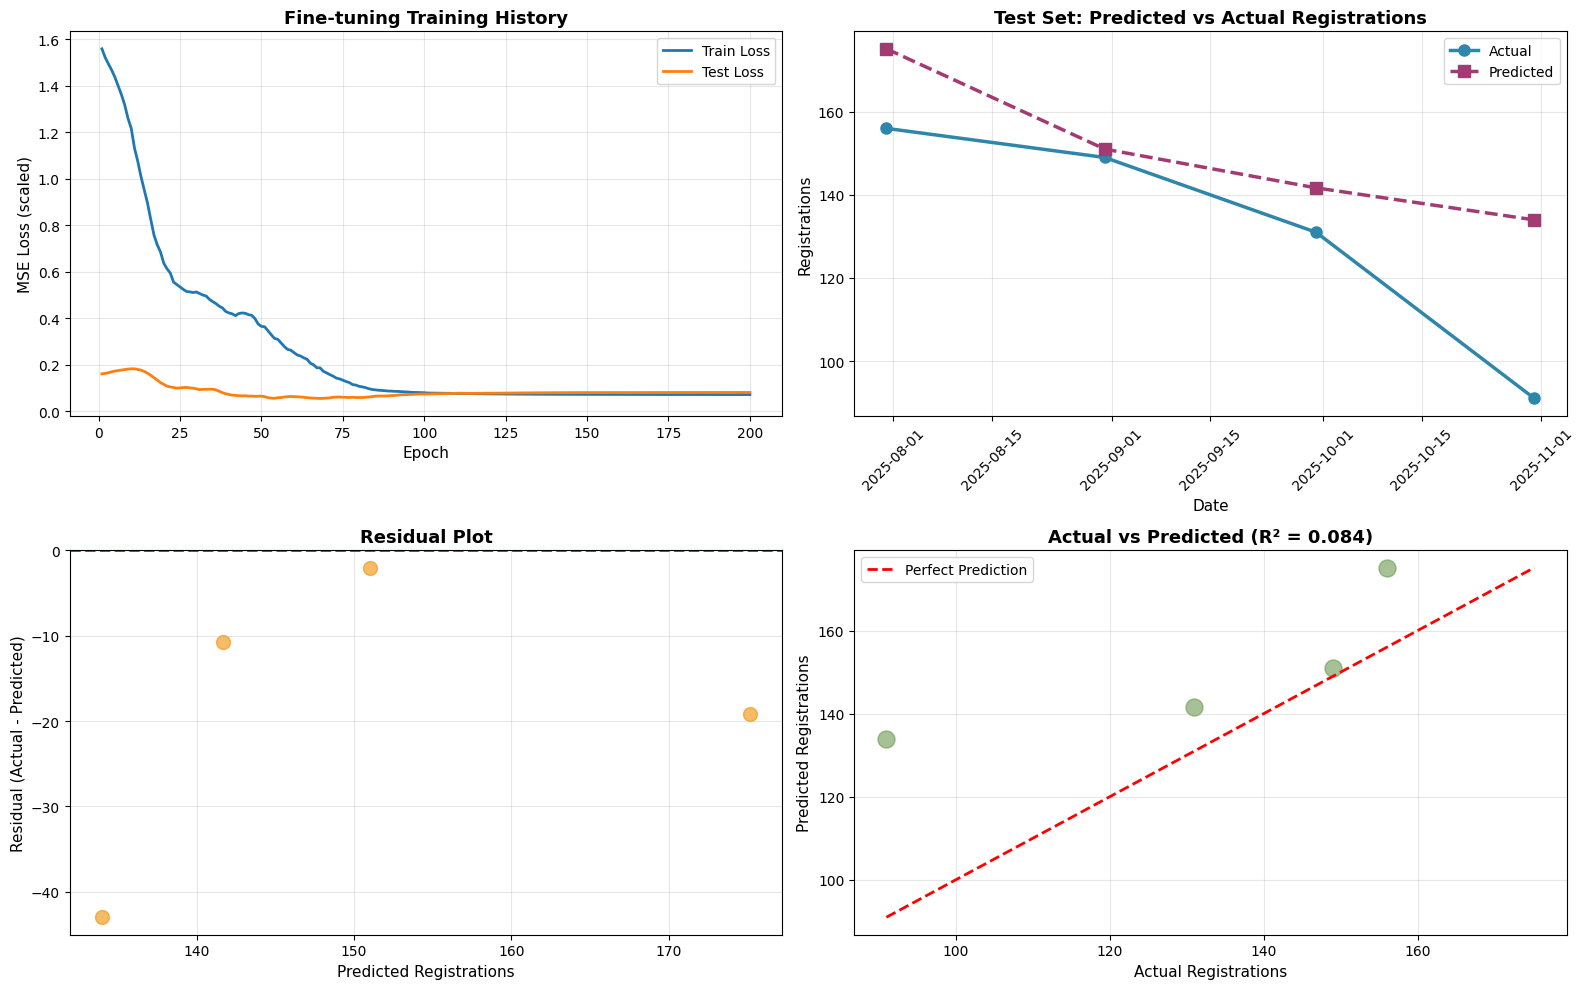


✓ Visualization saved as 'woodgreen_finetuning_results.png'


In [284]:
# ============================================================
# STEP 8: Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Training history
ax = axes[0, 0]
epochs_range = range(1, len(train_losses_ft) + 1)
ax.plot(epochs_range, train_losses_ft, label='Train Loss', linewidth=2)
ax.plot(epochs_range, test_losses_ft, label='Test Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss (scaled)', fontsize=11)
ax.set_title('Fine-tuning Training History', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Predictions vs Actual
ax = axes[0, 1]
ax.plot(results_df['Date'], results_df['Actual'], 'o-',
        label='Actual', linewidth=2.5, markersize=8, color='#2E86AB')
ax.plot(results_df['Date'], results_df['Predicted'], 's--',
        label='Predicted', linewidth=2.5, markersize=8, color='#A23B72')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Registrations', fontsize=11)
ax.set_title('Test Set: Predicted vs Actual Registrations', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 3. Residuals plot
ax = axes[1, 0]
ax.scatter(results_df['Predicted'], results_df['Error'],
          s=100, alpha=0.6, color='#F18F01')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Registrations', fontsize=11)
ax.set_ylabel('Residual (Actual - Predicted)', fontsize=11)
ax.set_title('Residual Plot', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# 4. Actual vs Predicted scatter
ax = axes[1, 1]
min_val = min(results_df['Actual'].min(), results_df['Predicted'].min())
max_val = max(results_df['Actual'].max(), results_df['Predicted'].max())
ax.scatter(results_df['Actual'], results_df['Predicted'],
          s=150, alpha=0.6, color='#6A994E')
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Registrations', fontsize=11)
ax.set_ylabel('Predicted Registrations', fontsize=11)
ax.set_title(f'Actual vs Predicted (R² = {r2_ft:.3f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('woodgreen_finetuning_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'woodgreen_finetuning_results.png'")


GENERATING PREDICTIONS ON FULL DATASET


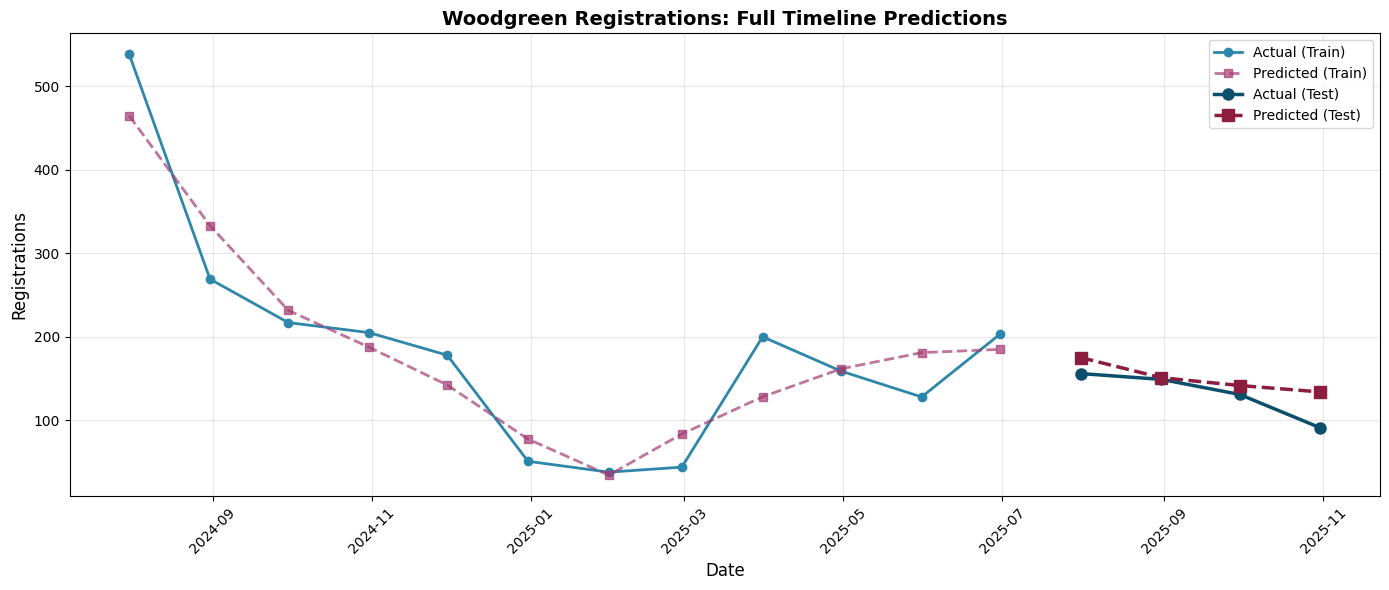


✓ Full timeline visualization saved as 'woodgreen_full_timeline.png'


In [285]:
# ============================================================
# STEP 9: Full Dataset Predictions (Train + Test)
# ============================================================

print("\n" + "="*70)
print("GENERATING PREDICTIONS ON FULL DATASET")
print("="*70)

# Create dataset for all available indices
all_dataset_wg = WoodgreenDataset(
    X_wg_scaled, y_wg_scaled, WINDOW_SIZE_WG, FORECAST_HORIZON, all_indices_wg
)
all_loader_wg = DataLoader(all_dataset_wg, batch_size=BATCH_SIZE_WG, shuffle=False)

model_finetuned.eval()
all_predictions = []

with torch.no_grad():
    for X_batch, _ in all_loader_wg:
        X_batch = X_batch.to(device)
        outputs = model_finetuned(X_batch)
        
        if FORECAST_HORIZON == 1:
            outputs = outputs.squeeze(-1)
        
        all_predictions.append(outputs.cpu().numpy())

all_predictions = np.concatenate(all_predictions)

# Inverse transform
if FORECAST_HORIZON == 1:
    all_preds_original = scaler_y_wg.inverse_transform(
        all_predictions.reshape(-1, 1)
    ).flatten()
else:
    all_preds_original = scaler_y_wg.inverse_transform(all_predictions)

# Get dates for all predictions
all_pred_dates = woodgreen_features.index[all_indices_wg]

# Create full results DataFrame
full_results = pd.DataFrame({
    'Date': all_pred_dates,
    'Actual': y_woodgreen.values[all_indices_wg],
    'Predicted': all_preds_original if FORECAST_HORIZON == 1 else all_preds_original[:, 0]
})

# Mark train/test split
full_results['Dataset'] = ['Train' if i in train_indices_wg else 'Test'
                           for i in all_indices_wg]

# Plot full timeline
plt.figure(figsize=(14, 6))

train_data = full_results[full_results['Dataset'] == 'Train']
test_data = full_results[full_results['Dataset'] == 'Test']

plt.plot(train_data['Date'], train_data['Actual'],
        'o-', label='Actual (Train)', linewidth=2, markersize=6, color='#2E86AB')
plt.plot(train_data['Date'], train_data['Predicted'],
        's--', label='Predicted (Train)', linewidth=2, markersize=6, color='#A23B72', alpha=0.7)

plt.plot(test_data['Date'], test_data['Actual'],
        'o-', label='Actual (Test)', linewidth=2.5, markersize=8, color='#0B4F6C')
plt.plot(test_data['Date'], test_data['Predicted'],
        's--', label='Predicted (Test)', linewidth=2.5, markersize=8, color='#8B1E3F')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Registrations', fontsize=12)
plt.title('Woodgreen Registrations: Full Timeline Predictions',
         fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('woodgreen_full_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Full timeline visualization saved as 'woodgreen_full_timeline.png'")

In [286]:
# ============================================================
# STEP 10: Summary and Model Comparison
# ============================================================

print("\n" + "="*70)
print("FINE-TUNING COMPLETE - SUMMARY")
print("="*70)

print(f"\nModel Configuration:")
print(f"  Total features: {len(all_features_wg)}")
print(f"    - Economic features: {len(economic_features)}")
print(f"    - Macro features: {len(macro_features)}")
print(f"    - Autoregressive lags: {N_LAGS}")
print(f"  Window size: {WINDOW_SIZE_WG} months")
print(f"  Forecast horizon: {FORECAST_HORIZON} month(s)")
print(f"  Training samples: {len(train_indices_wg)}")
print(f"  Test samples: {len(test_indices_wg)}")

print(f"\nModel Performance:")
print(f"  Test RMSE: {rmse_ft:.2f} registrations")
print(f"  Test MAE: {mae_ft:.2f} registrations")
print(f"  Test R²: {r2_ft:.4f}")

print(f"\nModel saved as: best_lstm_woodgreen_finetuned.pth")

print("\n" + "="*70)
print("KEY FEATURES OF THIS IMPLEMENTATION:")
print("="*70)
print("✓ Autoregressive features (previous registration values)")
print("✓ Multi-step prediction capability (configurable horizon)")
print("✓ Transfer learning from pre-trained economic model")
print("✓ Time-based train/test split")
print("✓ Comprehensive evaluation metrics")
print("✓ Full timeline visualization")
print("\nTo predict multiple months ahead, change FORECAST_HORIZON to 3, 6, etc.")
print("="*70)


FINE-TUNING COMPLETE - SUMMARY

Model Configuration:
  Total features: 12
    - Economic features: 8
    - Macro features: 2
    - Autoregressive lags: 2
  Window size: 4 months
  Forecast horizon: 1 month(s)
  Training samples: 12
  Test samples: 4

Model Performance:
  Test RMSE: 24.14 registrations
  Test MAE: 18.71 registrations
  Test R²: 0.0844

Model saved as: best_lstm_woodgreen_finetuned.pth

KEY FEATURES OF THIS IMPLEMENTATION:
✓ Autoregressive features (previous registration values)
✓ Multi-step prediction capability (configurable horizon)
✓ Transfer learning from pre-trained economic model
✓ Time-based train/test split
✓ Comprehensive evaluation metrics
✓ Full timeline visualization

To predict multiple months ahead, change FORECAST_HORIZON to 3, 6, etc.


In [290]:
# ============================================================
# FUTURE PREDICTION: November 2025
# ============================================================

print("="*70)
print("PREDICTING NOVEMBER 2025 REGISTRATIONS")
print("="*70)

# Check the latest data we have
print(f"\nLatest available data:")
print(f"  Date: {woodgreen_features.index[-1]}")
print(f"  Registrations: {woodgreen_features['registrations'].iloc[-1]}")

# To predict November 2025, we need:
# 1. Economic features for November 2025 (we'll use October's or project forward)
# 2. Autoregressive features (last 3 months of registrations)

# Check if we have November data or need to project
target_date = pd.Timestamp('2025-11-30')
latest_date = woodgreen_features.index[-1]

print(f"\nTarget prediction date: {target_date}")
print(f"Latest data date: {latest_date}")

if target_date <= latest_date:
    print("\n⚠ November 2025 data already exists in the dataset!")
    print("  Showing actual value for comparison.")
else:
    print(f"\n✓ Predicting {(target_date.year - latest_date.year) * 12 + (target_date.month - latest_date.month)} month(s) into the future")

PREDICTING NOVEMBER 2025 REGISTRATIONS

Latest available data:
  Date: 2025-10-31 00:00:00
  Registrations: 91

Target prediction date: 2025-11-30 00:00:00
Latest data date: 2025-10-31 00:00:00

✓ Predicting 1 month(s) into the future


In [291]:
# ============================================================
# Prepare Input Features for November 2025 Prediction
# ============================================================

# We need a window of WINDOW_SIZE_WG months of features to predict
# Since we want to predict November, we need features from the last WINDOW_SIZE_WG months

# Get the last WINDOW_SIZE_WG months of data
input_window_data = woodgreen_features.iloc[-WINDOW_SIZE_WG:].copy()

print(f"\nUsing last {WINDOW_SIZE_WG} months of data for prediction:")
print(f"  Date range: {input_window_data.index[0]} to {input_window_data.index[-1]}")

# For November prediction, we need to create the input features
# Since October 2025 is the latest, we need to construct November's features

# Method 1: Use last available economic features (October 2025)
# and create autoregressive features from recent registrations

# Get October 2025 economic features (assume they persist to November)
oct_features = woodgreen_features[economic_features + macro_features].iloc[-1].copy()

print(f"\nEconomic features (using October 2025 values):")
for feat in economic_features[:3]:
    print(f"  {feat}: {oct_features[feat]:.2f}")
print("  ...")

# For autoregressive features, we need the last 3 months of registrations
# For November prediction:
# - registrations_lag_1 = October (most recent)
# - registrations_lag_2 = September
# - registrations_lag_3 = August

recent_registrations = woodgreen_features['registrations'].iloc[-3:].values
print(f"\nAutoregressive features (last 3 months of registrations):")
print(f"  August 2025: {recent_registrations[0]}")
print(f"  September 2025: {recent_registrations[1]}")
print(f"  October 2025: {recent_registrations[2]}")

# Create November features
nov_features = oct_features.to_dict()
nov_features['registrations_lag_1'] = recent_registrations[2]  # October
nov_features['registrations_lag_2'] = recent_registrations[1]  # September
nov_features['registrations_lag_3'] = recent_registrations[0]  # August

# Convert to DataFrame
nov_features_df = pd.DataFrame([nov_features], columns=all_features_wg)

print(f"\nNovember 2025 feature vector shape: {nov_features_df.shape}")
print(f"Features: {list(nov_features_df.columns)}")


Using last 4 months of data for prediction:
  Date range: 2025-07-31 00:00:00 to 2025-10-31 00:00:00

Economic features (using October 2025 values):
  unemployed_count: 1435.00
  employment_to_pop_ratio: 0.58
  prop_1.0: 0.82
  ...

Autoregressive features (last 3 months of registrations):
  August 2025: 149
  September 2025: 131
  October 2025: 91

November 2025 feature vector shape: (1, 12)
Features: ['unemployed_count', 'employment_to_pop_ratio', 'prop_1.0', 'prop_2.0', 'share_temporary', 'hourly_wage_mean', 'hourly_wage_median', 'job_loss_total', 'goc_2y_benchmark', 'spread_10y_2y', 'registrations_lag_1', 'registrations_lag_2']


In [292]:
# ============================================================
# Create Input Sequence and Make Prediction
# ============================================================

# We need to create a sequence of WINDOW_SIZE_WG months
# Using the last WINDOW_SIZE_WG months from the existing data

# Get the last WINDOW_SIZE_WG rows of features
input_sequence = woodgreen_features[all_features_wg].iloc[-WINDOW_SIZE_WG:].values

print(f"Input sequence shape: {input_sequence.shape}")
print(f"  ({WINDOW_SIZE_WG} months × {len(all_features_wg)} features)")

# Scale the input using the same scaler
input_sequence_scaled = scaler_X_wg.transform(input_sequence)

# Convert to tensor and add batch dimension
input_tensor = torch.from_numpy(input_sequence_scaled).float().unsqueeze(0)  # (1, window, features)
input_tensor = input_tensor.to(device)

print(f"\nInput tensor shape: {input_tensor.shape}")
print(f"  Batch size: 1")
print(f"  Sequence length: {WINDOW_SIZE_WG}")
print(f"  Features: {len(all_features_wg)}")

# Make prediction
model_finetuned.eval()
with torch.no_grad():
    prediction_scaled = model_finetuned(input_tensor)
    
    # Squeeze to get scalar
    if FORECAST_HORIZON == 1:
        prediction_scaled = prediction_scaled.squeeze(-1)
    
    prediction_scaled_np = prediction_scaled.cpu().numpy()

print(f"\nPrediction (scaled): {prediction_scaled_np[0]:.4f}")

# Inverse transform to get actual registration count
if FORECAST_HORIZON == 1:
    nov_prediction = scaler_y_wg.inverse_transform(prediction_scaled_np.reshape(-1, 1))[0, 0]
else:
    nov_prediction = scaler_y_wg.inverse_transform(prediction_scaled_np.reshape(-1, FORECAST_HORIZON))[0, 0]

print(f"\n" + "="*70)
print(f"PREDICTION FOR NOVEMBER 2025")
print("="*70)
print(f"\n  Predicted Registrations: {nov_prediction:.0f}")
print(f"\n" + "="*70)

Input sequence shape: (4, 12)
  (4 months × 12 features)

Input tensor shape: torch.Size([1, 4, 12])
  Batch size: 1
  Sequence length: 4
  Features: 12

Prediction (scaled): -0.4788

PREDICTION FOR NOVEMBER 2025

  Predicted Registrations: 116



In [293]:
# ============================================================
# Prediction Confidence Analysis
# ============================================================

print("\n" + "="*70)
print("PREDICTION CONTEXT AND CONFIDENCE")
print("="*70)

# Show recent trend
recent_months = woodgreen_features['registrations'].iloc[-6:]
print(f"\nRecent registration trend (last 6 months):")
for date, value in recent_months.items():
    print(f"  {date.strftime('%B %Y')}: {value}")

# Calculate trend statistics
print(f"\n  Mean (last 6 months): {recent_months.mean():.1f}")
print(f"  Std (last 6 months): {recent_months.std():.1f}")
print(f"  Min: {recent_months.min()}")
print(f"  Max: {recent_months.max()}")

# Compare prediction to recent average
recent_avg = recent_months.mean()
diff_from_avg = nov_prediction - recent_avg
pct_diff = (diff_from_avg / recent_avg) * 100

print(f"\nPrediction Analysis:")
print(f"  November prediction: {nov_prediction:.0f}")
print(f"  Recent average (6 months): {recent_avg:.1f}")
print(f"  Difference: {diff_from_avg:+.1f} ({pct_diff:+.1f}%)")

# Trend direction
if nov_prediction > recent_months.iloc[-1]:
    trend = "↑ INCREASING"
elif nov_prediction < recent_months.iloc[-1]:
    trend = "↓ DECREASING"
else:
    trend = "→ STABLE"

print(f"  Trend vs October: {trend}")

# Model's prediction interval based on test performance
print(f"\nPrediction Uncertainty (based on test set MAE):")
print(f"  MAE: ±{mae_ft:.1f} registrations")
print(f"  Approximate 95% interval: [{nov_prediction - 2*mae_ft:.0f}, {nov_prediction + 2*mae_ft:.0f}]")

print("="*70)


PREDICTION CONTEXT AND CONFIDENCE

Recent registration trend (last 6 months):
  May 2025: 128
  June 2025: 203
  July 2025: 156
  August 2025: 149
  September 2025: 131
  October 2025: 91

  Mean (last 6 months): 143.0
  Std (last 6 months): 37.1
  Min: 91
  Max: 203

Prediction Analysis:
  November prediction: 116
  Recent average (6 months): 143.0
  Difference: -26.9 (-18.8%)
  Trend vs October: ↑ INCREASING

Prediction Uncertainty (based on test set MAE):
  MAE: ±18.7 registrations
  Approximate 95% interval: [79, 154]


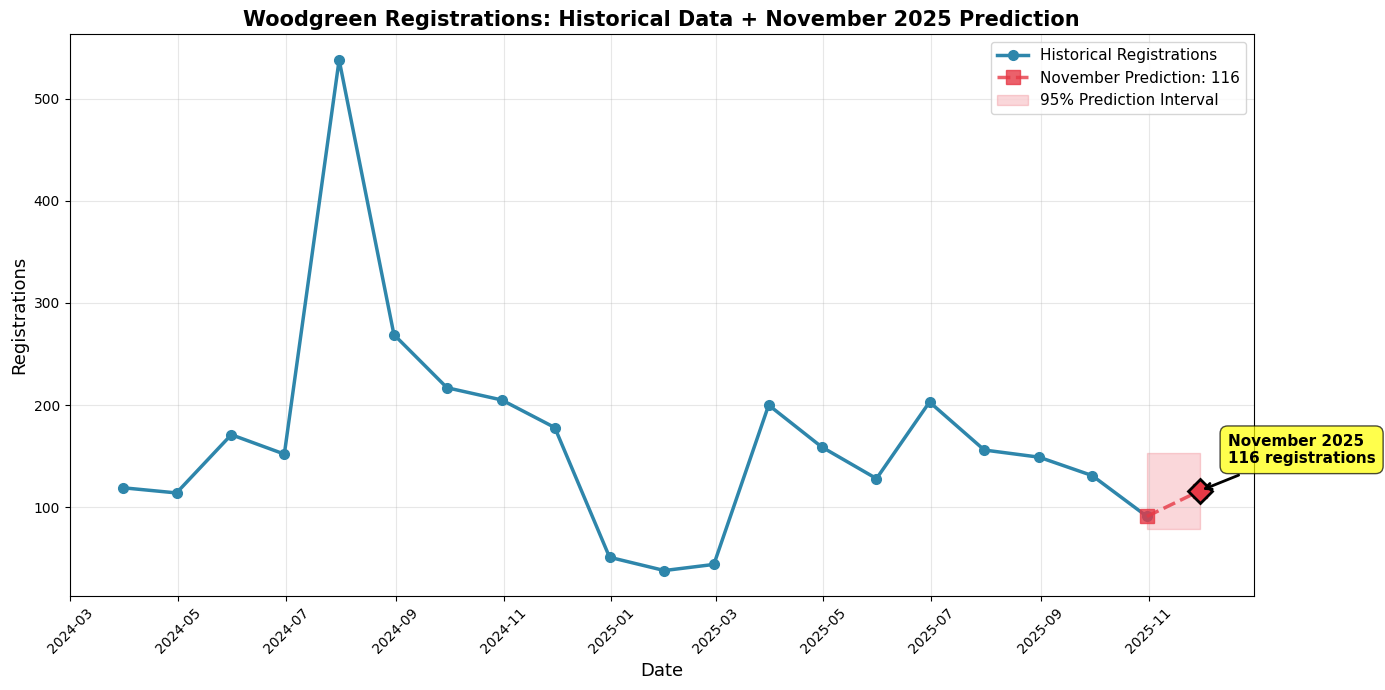


✓ Prediction visualization saved as 'november_2025_prediction.png'


In [294]:
# ============================================================
# Visualization: Prediction with Historical Context
# ============================================================

# Create extended timeline including the November prediction
fig, ax = plt.subplots(figsize=(14, 7))

# Historical data
historical_dates = woodgreen_features.index
historical_values = woodgreen_features['registrations'].values

# Plot historical data
ax.plot(historical_dates, historical_values, 
        'o-', label='Historical Registrations', 
        linewidth=2.5, markersize=7, color='#2E86AB')

# Add November prediction
nov_date = pd.Timestamp('2025-11-30')
ax.plot([historical_dates[-1], nov_date], 
        [historical_values[-1], nov_prediction],
        's--', label=f'November Prediction: {nov_prediction:.0f}',
        linewidth=2.5, markersize=10, color='#E63946', alpha=0.8)

# Add prediction marker
ax.plot(nov_date, nov_prediction, 
        'D', markersize=12, color='#E63946', 
        markeredgewidth=2, markeredgecolor='black')

# Add confidence interval
upper_bound = nov_prediction + 2*mae_ft
lower_bound = nov_prediction - 2*mae_ft
ax.fill_between([historical_dates[-1], nov_date], 
                [lower_bound, lower_bound], 
                [upper_bound, upper_bound],
                alpha=0.2, color='#E63946', 
                label=f'95% Prediction Interval')

# Add text annotation for prediction
ax.annotate(f'November 2025\n{nov_prediction:.0f} registrations', 
            xy=(nov_date, nov_prediction),
            xytext=(20, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=2),
            fontsize=11, fontweight='bold')

# Formatting
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Registrations', fontsize=13)
ax.set_title('Woodgreen Registrations: Historical Data + November 2025 Prediction', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('november_2025_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Prediction visualization saved as 'november_2025_prediction.png'")